<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/R3_TS2_alignement_Superimpose_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q morfeus-ml pandas numpy openpyxl


# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive', force_remount=True)


# ============================================================
# IMPORTS
# ============================================================

import os
import pandas as pd
import numpy as np

from morfeus import Sterimol, BuriedVolume, read_xyz


# ============================================================
# PATH
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"


# ============================================================
# YOUR FIXED XYZ NUMBERING
#
# DDQ       = 1–15
# Substrate = 16–rest
# C2        = 18
# H on C2   = 43
# R3 first  = 44
# R3        = 44–last atom
# ============================================================

C2_ATOM = 18
R3_START_ATOM = 44


# ============================================================
# R3 NAMES
#
# If filename is not listed here, filename itself is used.
# ============================================================

R3_names = {

    "RR_Me.xyz": "Me",
    "RR_Et.xyz": "Et",
    "RR_iPr.xyz": "i-Pr",
    "RR_nBu.xyz": "n-Bu",
    "RR_tBu.xyz": "t-Bu",
    "RR_Cy.xyz": "Cy",
    "RR_CH2CO2Me.xyz": "CH2CO2Me",
    "RR_CMe2CO2Me.xyz": "CMe2CO2Me",
    "RR_allyl.xyz": "CH2CH=CH2",
    "RR_CMe2CHCH2.xyz": "CMe2CH=CH2",
    "RR_CH2_dioxolane.xyz": "CH2-1,3-dioxolane",
    "RR_CH2Ph.xyz": "CH2Ph",
    "RR_CH2CN.xyz": "CH2CN",
    "RR_Ph.xyz": "Phenyl",
    "RR_vinyl.xyz": "CH=CH2",
    "RR_alkyne.xyz": "C#CH"
}


# ============================================================
# STORAGE
# ============================================================

results = []


# ============================================================
# GET ALL XYZ FILES
# ============================================================

xyz_files = sorted([

    f for f in os.listdir(xyz_folder)

    if f.lower().endswith(".xyz")

])


print("Number of XYZ files:", len(xyz_files))


# ============================================================
# PROCESS EVERY XYZ
# ============================================================

for file in xyz_files:

    print("\n====================================================")
    print("Processing:", file)
    print("====================================================")

    path = os.path.join(xyz_folder, file)

    try:

        # ----------------------------------------------------
        # READ XYZ
        # ----------------------------------------------------

        elements, coordinates = read_xyz(path)

        n_atoms = len(elements)


        # ----------------------------------------------------
        # CHECK NUMBERING
        # ----------------------------------------------------

        if n_atoms < R3_START_ATOM:

            raise ValueError(
                f"Only {n_atoms} atoms found; "
                f"R3 should start at atom {R3_START_ATOM}."
            )


        # ----------------------------------------------------
        # DEFINE R3
        #
        # Because your numbering is standardized:
        #
        # R3 = 44 through the last atom
        # ----------------------------------------------------

        R3_atoms = list(
            range(R3_START_ATOM, n_atoms + 1)
        )


        print(
            "R3 atoms:",
            R3_atoms
        )


        # ----------------------------------------------------
        # CHECK C18-C44 DISTANCE
        # ----------------------------------------------------

        c18 = coordinates[C2_ATOM - 1]

        c44 = coordinates[R3_START_ATOM - 1]

        c18_c44_distance = np.linalg.norm(
            c18 - c44
        )


        print(
            f"C18-C44 distance = "
            f"{c18_c44_distance:.3f} Å"
        )


        # ====================================================
        # STERIMOL
        #
        # YOUR DEFINED STERIC AXIS:
        #
        # C18 --------------------> C44
        # C2                         first R3 carbon
        #
        # IMPORTANT:
        # Morfeus indices are 1-based.
        # ====================================================

        keep_atoms = set(
            [C2_ATOM] + R3_atoms
        )


        # Exclude DDQ + remaining substrate atoms
        excluded_atoms = [

            i

            for i in range(1, n_atoms + 1)

            if i not in keep_atoms

        ]


        sterimol = Sterimol(

            elements,
            coordinates,

            dummy_index=C2_ATOM,

            attached_index=R3_START_ATOM,

            excluded_atoms=excluded_atoms,

            radii_type="crc",

            n_rot_vectors=3600

        )


        # ----------------------------------------------------
        # STERIMOL VALUES
        # ----------------------------------------------------

        B1 = sterimol.B_1_value

        B5 = sterimol.B_5_value

        L = sterimol.L_value


        print(
            f"Sterimol B1 = {B1:.3f} Å"
        )

        print(
            f"Sterimol B5 = {B5:.3f} Å"
        )

        print(
            f"Sterimol L  = {L:.3f} Å"
        )


        # ====================================================
        # CUSTOM R3 %VBUR
        #
        # Center = C18
        #
        # Only R3 atoms are allowed to contribute.
        #
        # C18 itself is the center and is automatically
        # excluded from the buried-volume contribution.
        # ====================================================

        vbur_excluded_atoms = [

            i

            for i in range(1, n_atoms + 1)

            if i not in R3_atoms

        ]


        buried = BuriedVolume(

            elements,

            coordinates,

            metal_index=C2_ATOM,

            excluded_atoms=vbur_excluded_atoms,

            radius=3.5,

            include_hs=False,

            radii_type="bondi"

        )


        # ----------------------------------------------------
        # %VBUR
        # ----------------------------------------------------

        percent_vbur = buried.percent_buried_volume


        print(
            f"%Vbur = {percent_vbur:.3f} %"
        )


        # ====================================================
        # R3 NAME
        # ====================================================

        R3 = R3_names.get(

            file,

            os.path.splitext(file)[0]

        )


        # ====================================================
        # SAVE
        # ====================================================

        results.append({

            "File": file,

            "R3": R3,

            "C2 atom": C2_ATOM,

            "R3 first atom": R3_START_ATOM,

            "R3 atoms":
                f"{R3_START_ATOM}-{n_atoms}",

            "C18-C44 distance (Å)":
                c18_c44_distance,

            "B1 (Å)": B1,

            "B5 (Å)": B5,

            "L (Å)": L,

            "%Vbur": percent_vbur

        })


        print(
            "SUCCESS"
        )


    except Exception as e:

        print(
            f"ERROR in {file}: {e}"
        )


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(results)


# ============================================================
# SAVE CSV
# ============================================================

csv_file = os.path.join(

    xyz_folder,

    "R3_Sterimol_Vbur_results_new.csv"

)

df.to_csv(

    csv_file,

    index=False

)


# ============================================================
# SAVE EXCEL
# ============================================================

xlsx_file = os.path.join(

    xyz_folder,

    "R3_Sterimol_Vbur_results_new.xlsx"

)

df.to_excel(

    xlsx_file,

    index=False

)


# ============================================================
# DISPLAY
# ============================================================

print("\n")
print("====================================================")
print("CALCULATION COMPLETED")
print("====================================================")

print(
    "CSV   :", csv_file
)

print(
    "Excel :", xlsx_file
)

print("\nRESULTS:")

display(df)

Mounted at /content/drive
Number of XYZ files: 34

Processing: RR_CH2-Ph.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]
C18-C44 distance = 1.529 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 5.853 Å
Sterimol L  = 6.870 Å


/tmp/ipykernel_784/375439761.py:289: DeprecationWarning: 'percent_buried_volume' is deprecated. Use 'fraction_buried_volume'.
  percent_vbur = buried.percent_buried_volume


%Vbur = 0.272 %
SUCCESS

Processing: RR_CH2-dioxane.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]
C18-C44 distance = 1.529 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 5.246 Å
Sterimol L  = 6.142 Å
%Vbur = 0.264 %
SUCCESS

Processing: RR_CH2CN.xyz
R3 atoms: [44, 45, 46, 47, 48]
C18-C44 distance = 1.540 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 3.992 Å
Sterimol L  = 4.439 Å
%Vbur = 0.240 %
SUCCESS

Processing: RR_CH2CO2Me.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
C18-C44 distance = 1.530 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 4.957 Å
Sterimol L  = 5.778 Å
%Vbur = 0.265 %
SUCCESS

Processing: RR_CMe2CO2Me.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
C18-C44 distance = 1.553 Å
Sterimol B1 = 2.841 Å
Sterimol B5 = 5.068 Å
Sterimol L  = 5.513 Å
%Vbur = 0.370 %
SUCCESS

Processing: RR_Cy.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
C18-C44 distance = 1.539 Å
Sterimol B1 = 2.007 Å
Sterimol B5 = 3.676 

,File,R3,C2 atom,R3 first atom,R3 atoms,C18-C44 distance (Å),B1 (Å),B5 (Å),L (Å),%Vbur
0,RR_CH2-Ph.xyz,RR_CH2-Ph,18,44,44-57,1.529416,1.700000,5.852931,6.869516,0.271588
1,RR_CH2-dioxane.xyz,RR_CH2-dioxane,18,44,44-56,1.528873,1.700000,5.245980,6.141713,0.263849
2,RR_CH2CN.xyz,CH2CN,18,44,44-48,1.539665,1.700000,3.992223,4.438541,0.239675
3,RR_CH2CO2Me.xyz,CH2CO2Me,18,44,44-53,1.529564,1.700000,4.957261,5.777883,0.264792
4,RR_CMe2CO2Me.xyz,CMe2CO2Me,18,44,44-59,1.552641,2.841477,5.068311,5.512985,0.370091
5,RR_Cy.xyz,Cy,18,44,44-60,1.539015,2.006980,3.676088,6.749453,0.292554
6,RR_Et.xyz,Et,18,44,44-50,1.529597,1.700000,3.255715,4.676969,0.238871
7,RR_Me-Propane.xyz,RR_Me-Propane,18,44,44-56,1.537140,1.700000,4.502030,5.803826,0.268752
8,RR_Me.xyz,Me,18,44,44-47,1.525097,1.700000,2.129183,3.625097,0.183697
9,RR_Ph.xyz,Phenyl,18,44,44-54,1.519774,1.700000,3.272252,6.899519,0.277593


                R3  C18_C44_dist        B1        B5         L  pct_Vbur  \
0           CH2-Ph      1.529416  1.700000  5.852931  6.869516  0.271588   
1      CH2-dioxane      1.528873  1.700000  5.245980  6.141713  0.263849   
2            CH2CN      1.539665  1.700000  3.992223  4.438541  0.239675   
3         CH2CO2Me      1.529564  1.700000  4.957261  5.777883  0.264792   
4        CMe2CO2Me      1.552641  2.841477  5.068311  5.512985  0.370091   
5               Cy      1.539015  2.006980  3.676088  6.749453  0.292554   
6               Et      1.529597  1.700000  3.255715  4.676969  0.238871   
7       Me-Propane      1.537140  1.700000  4.502030  5.803826  0.268752   
8               Me      1.525097  1.700000  2.129183  3.625097  0.183697   
9               Ph      1.519774  1.700000  3.272252  6.899519  0.277593   
10          alkene      1.509653  1.700000  3.180606  4.831029  0.228272   
11          alkyne      1.474722  1.700000  1.712028  5.247814  0.208774   
12          

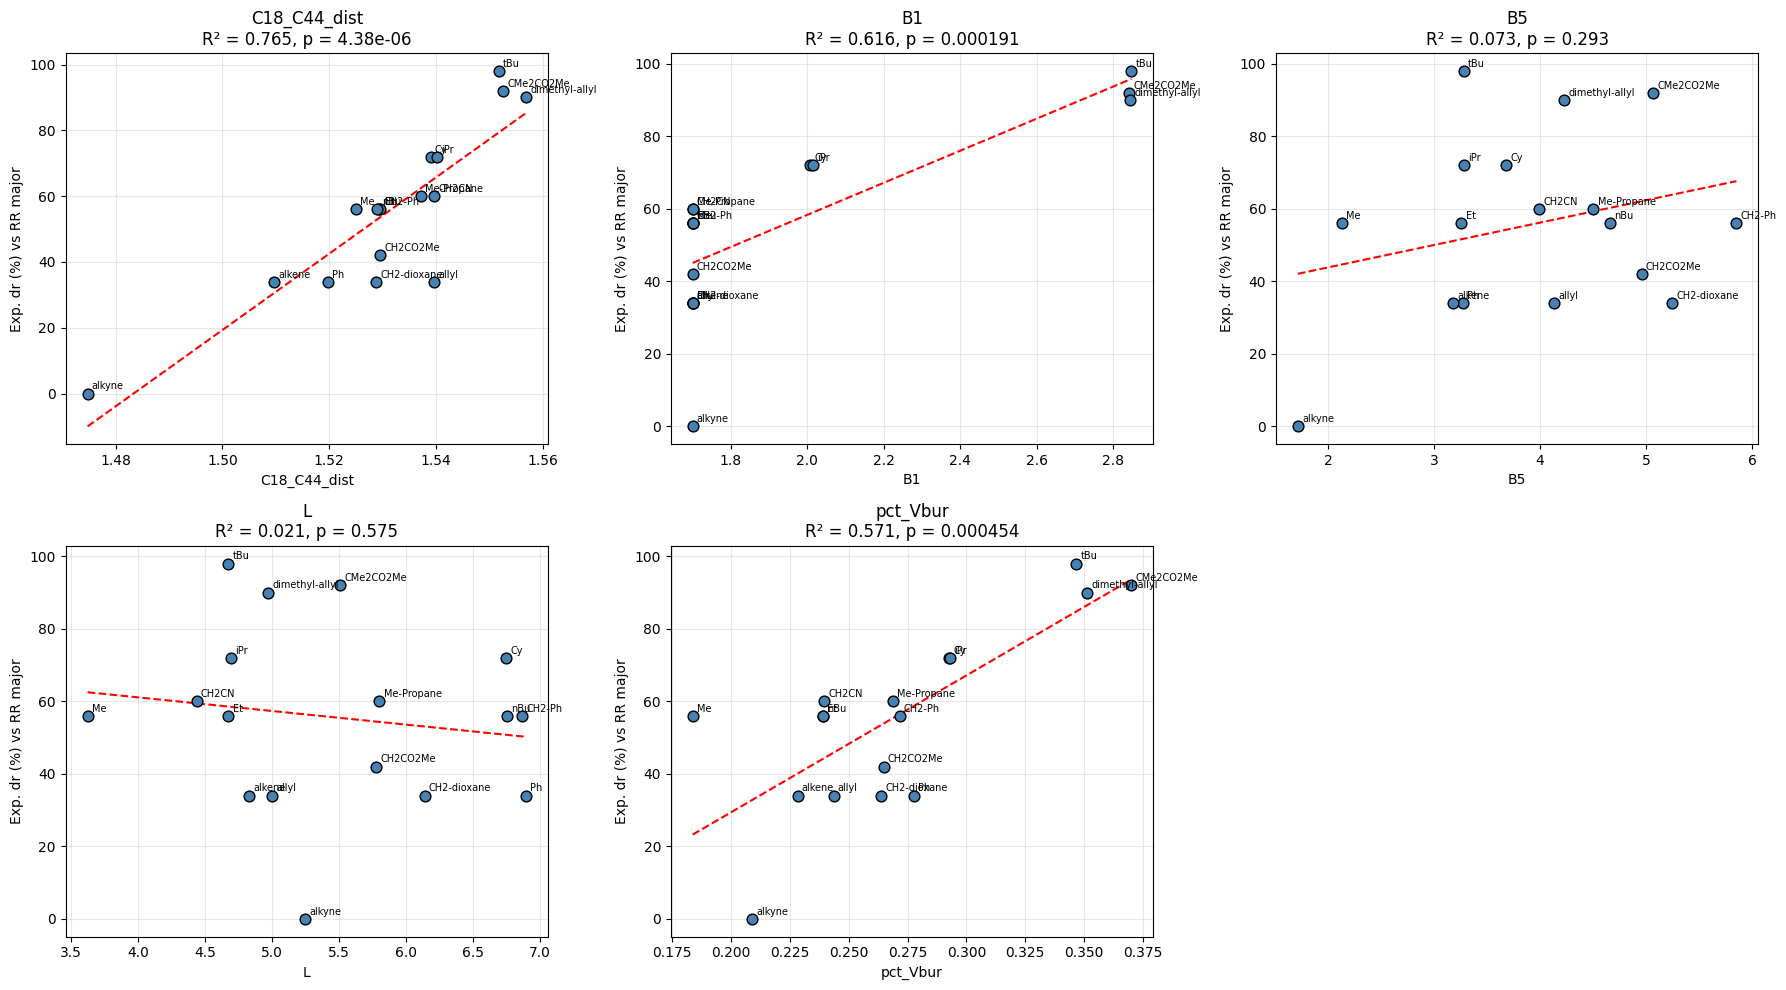


✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_descriptors_vs_dr.png


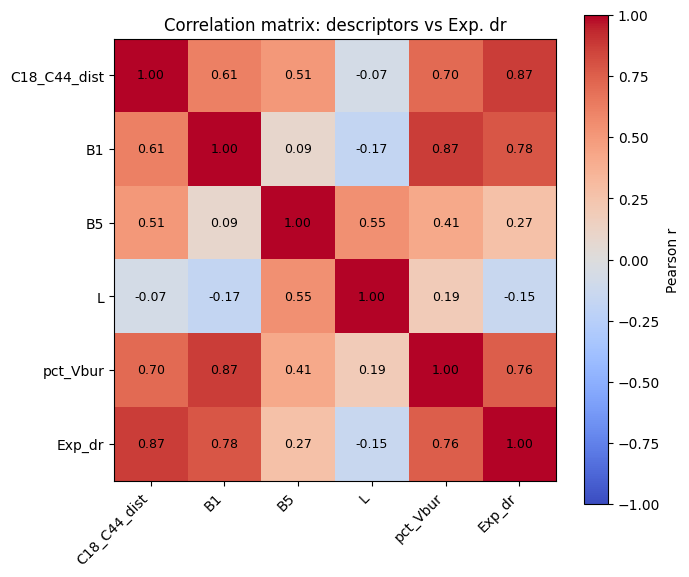

✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_heatmap.png


In [3]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# ============================================================
# 1. DATA — transcribed from your table (RR series, with Exp selectivity)
# ============================================================
data = {
    "R3": ["CH2-Ph", "CH2-dioxane", "CH2CN", "CH2CO2Me", "CMe2CO2Me", "Cy", "Et",
           "Me-Propane", "Me", "Ph", "alkene", "alkyne", "allyl", "dimethyl-allyl",
           "iPr", "nBu", "tBu"],
    "C18_C44_dist": [1.529416144, 1.528873288, 1.539664539, 1.529563911, 1.552641331,
                      1.539014927, 1.529596644, 1.537140364, 1.525096563, 1.519774304,
                      1.509652986, 1.474721903, 1.539668337, 1.556932552, 1.540264311,
                      1.52905731, 1.551790347],
    "B1": [1.7, 1.7, 1.7, 1.7, 2.841477401, 2.006980481, 1.7, 1.7, 1.7, 1.7, 1.7, 1.7,
           1.7, 2.845495002, 2.01483892, 1.7, 2.84782909],
    "B5": [5.852931423, 5.245979701, 3.992222701, 4.957261478, 5.068311164, 3.676088041,
           3.255714689, 4.502029815, 2.129182645, 3.272252159, 3.180605577, 1.712027791,
           4.128135092, 4.225435636, 3.276498467, 4.661634076, 3.280251337],
    "L": [6.869515854, 6.14171285, 4.438541422, 5.777883105, 5.512984644, 6.749453254,
          4.676969375, 5.803826209, 3.625096563, 6.899519327, 4.831029456, 5.247814367,
          5.00005738, 4.974717983, 4.698652697, 6.757457655, 4.676915531],
    "pct_Vbur": [0.271588474, 0.26384877, 0.239674571, 0.26479221, 0.370090617, 0.292553811,
                 0.2388709, 0.268752329, 0.183697121, 0.277592713, 0.228271757, 0.208773994,
                 0.243599748, 0.351233461, 0.293142005, 0.238969903, 0.346679324],
    "Exp_dr": [56, 34, 60, 42, 92, 72, 56, 60, 56, 34, 34, 0, 34, 90, 72, 56, 98],
}

df = pd.DataFrame(data)
print(df)

# ============================================================
# 2. CORRELATION ANALYSIS — Pearson r, R², p-value for each descriptor
# ============================================================
descriptors = ["C18_C44_dist", "B1", "B5", "L", "pct_Vbur"]
results = []

for desc in descriptors:
    r, p = stats.pearsonr(df[desc], df["Exp_dr"])
    results.append({"Descriptor": desc, "Pearson r": r, "R2": r**2, "p-value": p})

corr_summary = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nCorrelation with Exp. diastereoselectivity:")
print(corr_summary.to_string(index=False))

# ============================================================
# 3. INDIVIDUAL CORRELATION PLOTS (one per descriptor)
# ============================================================
out_dir = "/content/drive/MyDrive/xyz_files/superimposed_by_stereo"
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, desc in enumerate(descriptors):
    ax = axes[i]
    x = df[desc].values
    y = df["Exp_dr"].values

    # linear regression line
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.scatter(x, y, color="steelblue", s=60, edgecolor="black", zorder=3)
    ax.plot(x_line, y_line, color="red", linestyle="--", linewidth=1.5, zorder=2)

    # label each point with R3 name
    for xi, yi, label in zip(x, y, df["R3"]):
        ax.annotate(label, (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(desc)
    ax.set_ylabel("Exp. dr (%) vs RR major")
    ax.set_title(f"{desc}\nR² = {r**2:.3f}, p = {p:.3g}")
    ax.grid(alpha=0.3)

# remove unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plot_path = os.path.join(out_dir, "correlation_descriptors_vs_dr.png")
plt.savefig(plot_path, dpi=200)
plt.show()
print(f"\n✅ Saved: {plot_path}")

# ============================================================
# 4. CORRELATION HEATMAP (all descriptors + Exp_dr)
# ============================================================
corr_matrix = df[descriptors + ["Exp_dr"]].corr()

fig2, ax2 = plt.subplots(figsize=(7, 6))
im = ax2.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix)))
ax2.set_yticks(range(len(corr_matrix)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax2.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center",
                  color="black", fontsize=9)

fig2.colorbar(im, ax=ax2, label="Pearson r")
ax2.set_title("Correlation matrix: descriptors vs Exp. dr")
plt.tight_layout()

heatmap_path = os.path.join(out_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=200)
plt.show()
print(f"✅ Saved: {heatmap_path}")

In [5]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# ============================================================
# 1. LOAD DESCRIPTOR TABLE FROM EXCEL
# ============================================================
xyz_folder = "/content/drive/MyDrive/xyz_files"
excel_path = os.path.join(xyz_folder, "R3_Sterimol_Vbur_results_new.xlsx")

df = pd.read_excel(excel_path)
print(f"Loaded {len(df)} rows, columns: {df.columns.tolist()}\n")
df

Loaded 34 rows, columns: ['File', 'R3', 'C2 atom', 'R3 first atom', 'R3 atoms', 'C18-C44 distance (Å)', 'B1 (Å)', 'B5 (Å)', 'L (Å)', '%Vbur']



,File,R3,C2 atom,R3 first atom,R3 atoms,C18-C44 distance (Å),B1 (Å),B5 (Å),L (Å),%Vbur
0,RR_CH2-Ph.xyz,RR_CH2-Ph,18,44,44-57,1.529416,1.700000,5.852931,6.869516,0.271588
1,RR_CH2-dioxane.xyz,RR_CH2-dioxane,18,44,44-56,1.528873,1.700000,5.245980,6.141713,0.263849
2,RR_CH2CN.xyz,CH2CN,18,44,44-48,1.539665,1.700000,3.992223,4.438541,0.239675
3,RR_CH2CO2Me.xyz,CH2CO2Me,18,44,44-53,1.529564,1.700000,4.957261,5.777883,0.264792
4,RR_CMe2CO2Me.xyz,CMe2CO2Me,18,44,44-59,1.552641,2.841477,5.068311,5.512985,0.370091
5,RR_Cy.xyz,Cy,18,44,44-60,1.539015,2.006980,3.676088,6.749453,0.292554
6,RR_Et.xyz,Et,18,44,44-50,1.529597,1.700000,3.255715,4.676969,0.238871
7,RR_Me-Propane.xyz,RR_Me-Propane,18,44,44-56,1.537140,1.700000,4.502030,5.803826,0.268752
8,RR_Me.xyz,Me,18,44,44-47,1.525097,1.700000,2.129183,3.625097,0.183697
9,RR_Ph.xyz,Phenyl,18,44,44-54,1.519774,1.700000,3.272252,6.899519,0.277593


In [6]:
# ============================================================
# 2. ADD EXPERIMENTAL %DE COLUMN (manually provided, RR series only)
# ============================================================
exp_de = {
    "RR_CH2-Ph.xyz": 56,
    "RR_CH2-dioxane.xyz": 34,
    "RR_CH2CN.xyz": 60,
    "RR_CH2CO2Me.xyz": 42,
    "RR_CMe2CO2Me.xyz": 92,
    "RR_Cy.xyz": 72,
    "RR_Et.xyz": 56,
    "RR_Me-Propane.xyz": 60,
    "RR_Me.xyz": 56,
    "RR_Ph.xyz": 34,
    "RR_alkene.xyz": 34,
    "RR_alkyne.xyz": 0,
    "RR_allyl.xyz": 34,
    "RR_dimethyl-allyl.xyz": 90,
    "RR_iPr.xyz": 72,
    "RR_nBu.xyz": 56,
    "RR_tBu.xyz": 98,
}

df["Exp diastereo Selectivity (%) wrt RR (major)"] = df["File"].map(exp_de)

# Sanity check: any RR_ files that didn't get matched (spelling mismatch etc.)
missing = df[df["File"].astype(str).str.startswith("RR_") &
             df["Exp diastereo Selectivity (%) wrt RR (major)"].isna()]
if len(missing) > 0:
    print("⚠️ These RR files were NOT matched — check exact spelling in exp_de vs Excel 'File' column:")
    print(missing[["File"]])
else:
    print("✅ All RR files matched successfully.")

# ============================================================
# 3. DISPLAY FULL TABLE WITH NEW COLUMN
# ============================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df)

# Save the merged table back to Excel for reference
merged_path = os.path.join(xyz_folder, "R3_Sterimol_Vbur_with_ExpDE.xlsx")
df.to_excel(merged_path, index=False)
print(f"\n✅ Saved merged table: {merged_path}")

✅ All RR files matched successfully.
                     File                 R3  C2 atom  R3 first atom R3 atoms  C18-C44 distance (Å)    B1 (Å)    B5 (Å)     L (Å)     %Vbur  Exp diastereo Selectivity (%) wrt RR (major)
0           RR_CH2-Ph.xyz          RR_CH2-Ph       18             44    44-57              1.529416  1.700000  5.852931  6.869516  0.271588                                          56.0
1      RR_CH2-dioxane.xyz     RR_CH2-dioxane       18             44    44-56              1.528873  1.700000  5.245980  6.141713  0.263849                                          34.0
2            RR_CH2CN.xyz              CH2CN       18             44    44-48              1.539665  1.700000  3.992223  4.438541  0.239675                                          60.0
3         RR_CH2CO2Me.xyz           CH2CO2Me       18             44    44-53              1.529564  1.700000  4.957261  5.777883  0.264792                                          42.0
4        RR_CMe2CO2Me.xyz        

17 structures with experimental %DE for correlation

Descriptors used: ['C18-C44 distance (Å)', 'B1 (Å)', 'B5 (Å)', 'L (Å)', '%Vbur']

Correlation with Exp. %DE:
          Descriptor  Pearson r       R2  p-value
C18-C44 distance (Å)   0.874606 0.764935 0.000004
              B1 (Å)   0.784713 0.615775 0.000191
               %Vbur   0.755425 0.570666 0.000454
              B5 (Å)   0.270795 0.073330 0.293132
               L (Å)  -0.146219 0.021380 0.575495


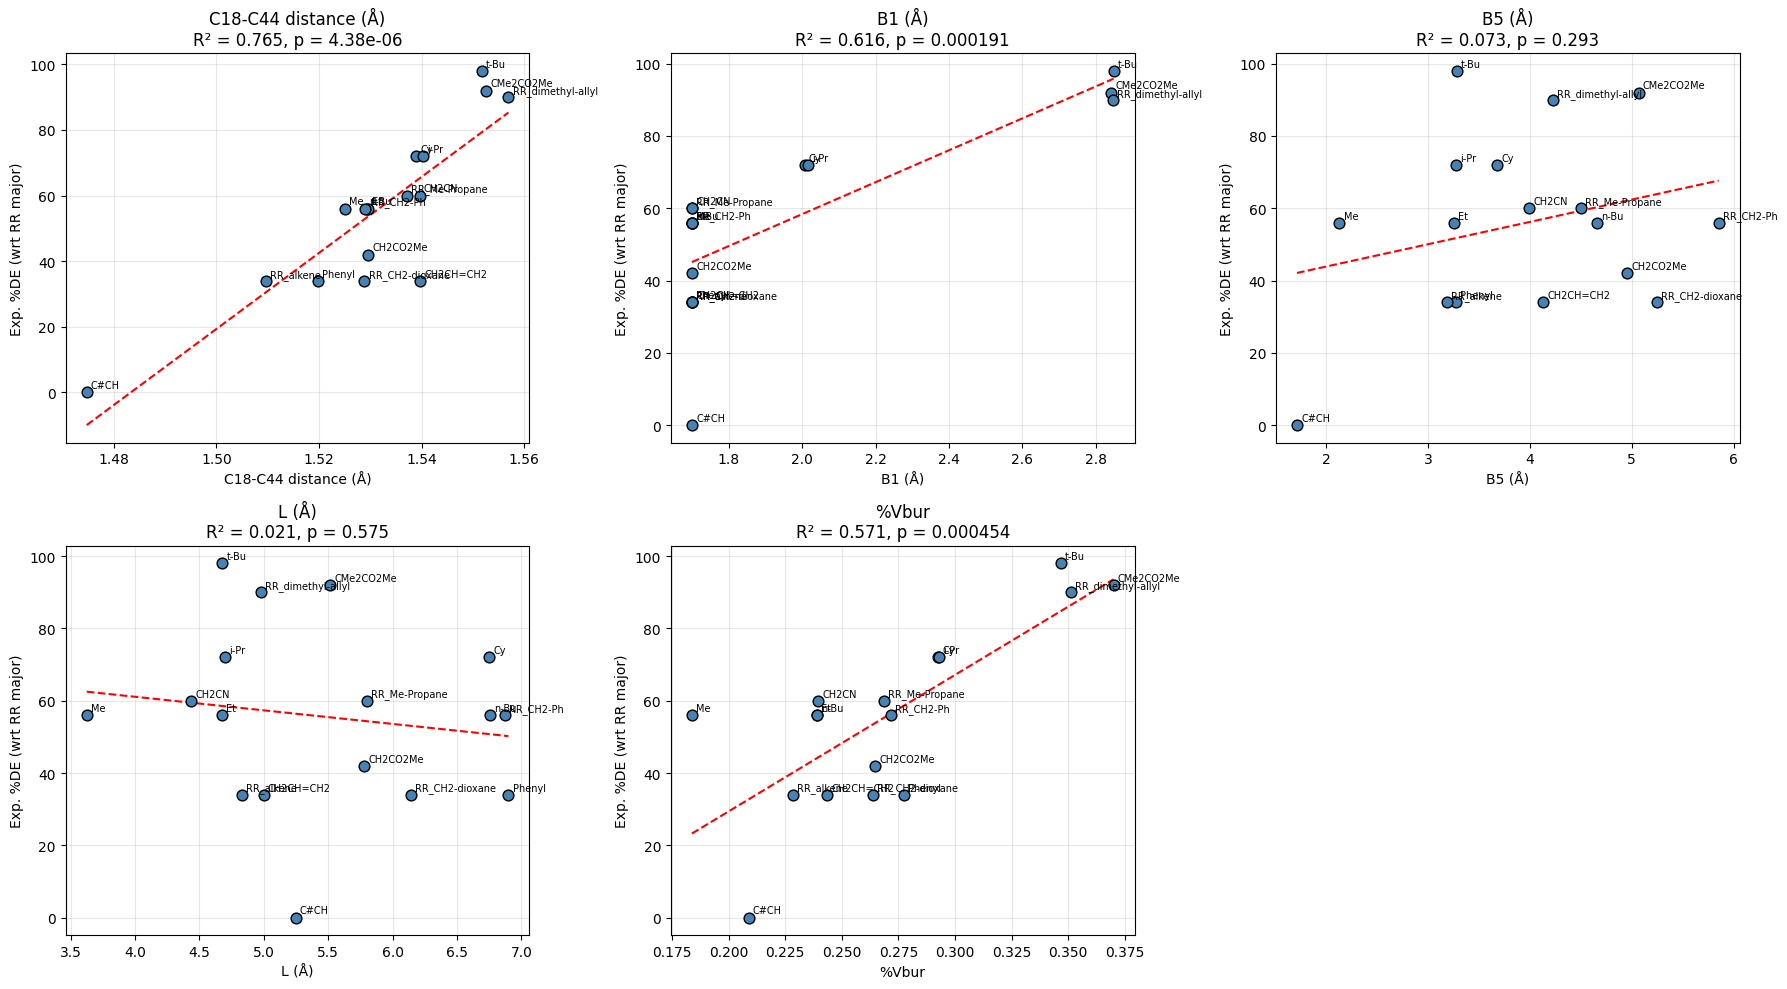


✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_descriptors_vs_DE.png


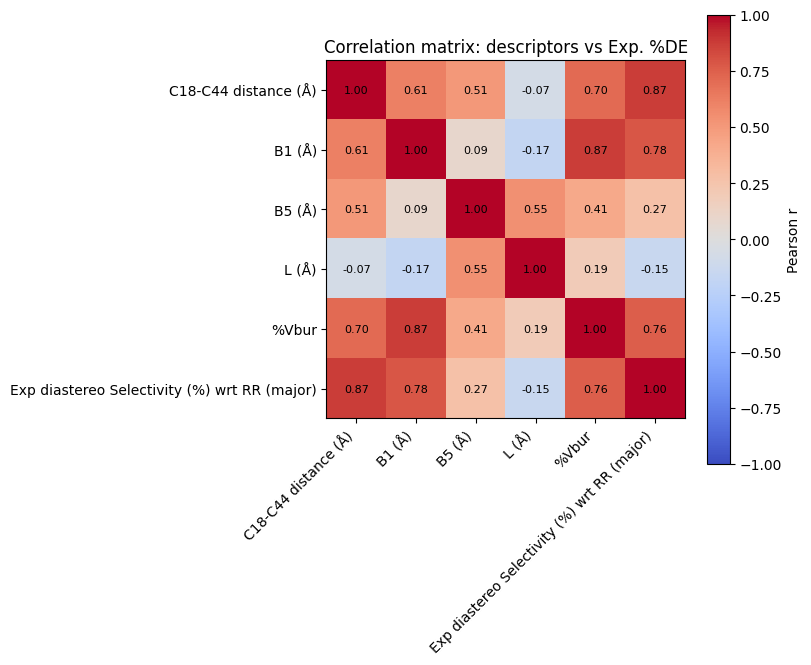

✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_heatmap_DE.png


In [7]:
# ============================================================
# 4. CORRELATION ANALYSIS (RR series only)
# ============================================================
de_col = "Exp diastereo Selectivity (%) wrt RR (major)"
df_rr = df[df[de_col].notna()].copy()
print(f"{len(df_rr)} structures with experimental %DE for correlation\n")

# Explicitly define descriptor columns (edit these to match your exact Excel headers if different)
descriptor_cols = [c for c in df.columns if c not in
                    ["File", "R3", "C2 atom", "R3 first atom", "R3 atoms", de_col]
                    and pd.api.types.is_numeric_dtype(df[c])]
print(f"Descriptors used: {descriptor_cols}")

results = []
for desc in descriptor_cols:
    x = df_rr[desc].values
    y = df_rr[de_col].values
    if np.std(x) == 0:
        continue
    r, p = stats.pearsonr(x, y)
    results.append({"Descriptor": desc, "Pearson r": r, "R2": r**2, "p-value": p})

corr_summary = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nCorrelation with Exp. %DE:")
print(corr_summary.to_string(index=False))

# ============================================================
# 5. CORRELATION SCATTER PLOTS (one per descriptor)
# ============================================================
out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
os.makedirs(out_dir, exist_ok=True)

n = len(descriptor_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

label_col = "R3" if "R3" in df_rr.columns else "File"

for i, desc in enumerate(descriptor_cols):
    ax = axes[i]
    x = df_rr[desc].values
    y = df_rr[de_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.scatter(x, y, color="steelblue", s=60, edgecolor="black", zorder=3)
    ax.plot(x_line, y_line, color="red", linestyle="--", linewidth=1.5, zorder=2)

    for xi, yi, label in zip(x, y, df_rr[label_col]):
        ax.annotate(str(label), (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(desc)
    ax.set_ylabel("Exp. %DE (wrt RR major)")
    ax.set_title(f"{desc}\nR² = {r**2:.3f}, p = {p:.3g}")
    ax.grid(alpha=0.3)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plot_path = os.path.join(out_dir, "correlation_descriptors_vs_DE.png")
plt.savefig(plot_path, dpi=200)
plt.show()
print(f"\n✅ Saved: {plot_path}")

# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================
corr_matrix = df_rr[descriptor_cols + [de_col]].corr()

fig2, ax2 = plt.subplots(figsize=(8, 7))
im = ax2.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix)))
ax2.set_yticks(range(len(corr_matrix)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax2.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig2.colorbar(im, ax=ax2, label="Pearson r")
ax2.set_title("Correlation matrix: descriptors vs Exp. %DE")
plt.tight_layout()

heatmap_path = os.path.join(out_dir, "correlation_heatmap_DE.png")
plt.savefig(heatmap_path, dpi=200)
plt.show()
print(f"✅ Saved: {heatmap_path}")